# OpenTouch Classification Training — Colab Setup
## 6.S985 Project — Direction B: Pre-Contact Intent Prediction

This notebook runs the three modality ablation experiments on Colab GPU.

**Before running**: Make sure you've selected a GPU runtime.
Runtime → Change runtime type → T4 GPU (free) or A100 (Colab Pro)

**Data**: Upload `preprocessed_data/` from your local machine to Google Drive first.

---
## 1. Check GPU

In [1]:
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU')

CUDA available: True
GPU: Tesla T4


---
## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Verify your data path — adjust if your Drive folder is named differently
import os
DRIVE_PROJECT = '/content/drive/MyDrive/6.S985/opentouch'
print('Files in project folder:')
print(os.listdir(DRIVE_PROJECT))

Mounted at /content/drive
Files in project folder:
['preprocessed_data.zip', 'logs']


---
## 3. Clone OpenTouch and Install Dependencies

In [3]:
# Clone the repo
!git clone https://github.com/OpenTouch-MIT/opentouch /content/opentouch
%cd /content/opentouch

# Install
!pip install -e . -q
!pip install datasets opencv-python -q

print('Install complete')

Cloning into '/content/opentouch'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 69 (delta 7), reused 69 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 3.93 MiB | 27.75 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/opentouch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for opentouch (pyproject.toml) ... done
Install complete


---
## 4. Copy Preprocessed Data from Drive

Upload the `preprocessed_data/` folder from your local machine to Google Drive first.
From your local machine:
```
# Zip and upload to Drive manually, or use rclone
cd /Users/cassandrahe/Documents/6.S985/opentouch
zip -r preprocessed_data.zip preprocessed_data/
```
Then upload `preprocessed_data.zip` to `My Drive/6.S985/`

In [4]:
# Copy preprocessed data from Drive to Colab local storage (faster I/O)
!unzip -q {DRIVE_PROJECT}/preprocessed_data.zip -d /content/opentouch/

# Verify
!ls preprocessed_data/classification_peak/

data-00000-of-00008.arrow  data-00004-of-00008.arrow  dataset_info.json
data-00001-of-00008.arrow  data-00005-of-00008.arrow  label_info.json
data-00002-of-00008.arrow  data-00006-of-00008.arrow  state.json
data-00003-of-00008.arrow  data-00007-of-00008.arrow


---
## 5. HuggingFace Login (for DINOv3 if approved)

Skip this if using DINOv2 fallback.

In [5]:
# Uncomment and run if DINOv3 access has been approved
from huggingface_hub import login
login()  # paste your HF token when prompted

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


---
## 6. Run Ablation Experiments

Three runs comparing modality combinations for grip type classification.
The gap between runs quantifies the value of each modality for Direction B.

### Run 1: Visual Only

In [24]:
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run1_visual_only_v5 \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,10:01:09 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7945550cf5c0>
└ # D2 [2 B]
2026-04-06,10:03:15 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x79455467dc80>
└ # D2 [2 B]
2026-04-06,10:05:18 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,10:05:18 | INFO | Discovered num_classes from data: 28
2026-04-06,10:05:18 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [25]:
!cp -r /content/opentouch/logs/run1_visual_only_v5 \
    /content/drive/MyDrive/6.S985/opentouch/logs/

In [33]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run1_visual_only_v5/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual']  Epoch: 30
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 1437.25it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run1_visual_only_v5/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run1_visual_only_v5/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power Sp

### Run 2: Visual + Pose

In [26]:
# Run 2: Visual + pose — Direction B core baseline (pre-contact only)
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual pose \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run2_visual_pose \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,13:25:55 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x79a57fda6b40>
└ # D2 [2 B]
2026-04-06,13:27:59 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x79a57e150d80>
└ # D2 [2 B]
2026-04-06,13:30:00 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,13:30:00 | INFO | Discovered num_classes from data: 28
2026-04-06,13:30:00 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [31]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run2_visual_pose/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual', 'pose']  Epoch: 29
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 668.14it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run2_visual_pose/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run2_visual_pose/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power S

In [34]:
!cp -r /content/opentouch/logs/run2_visual_pose \
    /content/drive/MyDrive/6.S985/opentouch/logs/

### Run 3: Visual + Pose + Tactile

In [35]:
# Run 3: Visual + pose + tactile — upper bound with contact signal
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual pose tactile \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run3_visual_pose_tactile \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,18:24:39 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x79fa82bb6640>
└ # D2 [2 B]
2026-04-06,18:26:43 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x79fa803e5a80>
└ # D2 [2 B]
2026-04-06,18:28:47 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,18:28:47 | INFO | Discovered num_classes from data: 28
2026-04-06,18:28:47 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--facebook--dinov3-vitb16-pretrain-lvd1689m/snapshots/5931719e67bbdb9737e363e781fb0c67687896bc/config.json
Model config DINOv3ViTConfig {
  "apply_layernorm": true,
  "architectures": [
    "DINOv3ViTModel"
  ],
  "attention_dropout": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_size": 768,
  "image_

In [36]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run3_visual_pose_tactile/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual', 'pose', 'tactile']  Epoch: 29
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 691.27it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run3_visual_pose_tactile/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run3_visual_pose_tactile/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extensi

In [37]:
!cp -r /content/opentouch/logs/run3_visual_pose_tactile \
    /content/drive/MyDrive/6.S985/opentouch/logs/

---
## 7. Collect Results

=== Results Summary ===
        Run              Modalities Test Accuracy Macro F1 Train Loss (ep.29)
          1                  Visual         31.9%    0.169              1.041
          2           Visual + Pose         30.0%    0.135              0.773
          3 Visual + Pose + Tactile         28.9%    0.144              0.758
4 (pending)               Pose only           TBD      TBD                TBD


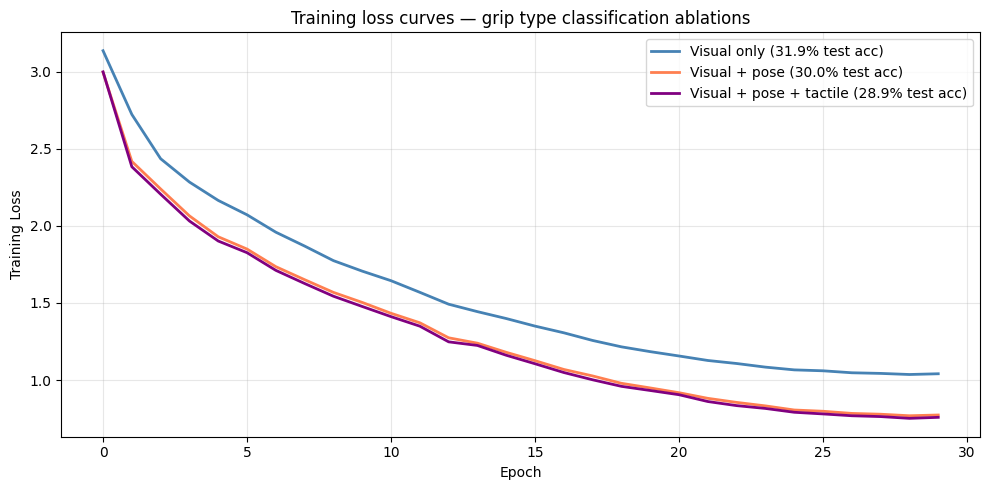

Saved to Drive


In [38]:
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(30))

# Training losses from all runs
run1_loss = [3.1355, 2.7223, 2.4351, 2.2837, 2.1646, 2.0714, 1.9586, 1.8686,
             1.7742, 1.7061, 1.6440, 1.5687, 1.4917, 1.4434, 1.3987, 1.3496,
             1.3062, 1.2565, 1.2152, 1.1840, 1.1558, 1.1267, 1.1071, 1.0836,
             1.0658, 1.0598, 1.0470, 1.0429, 1.0358, 1.0406]

run2_loss = [2.9956, 2.4177, 2.2390, 2.0644, 1.9289, 1.8492, 1.7350, 1.6506,
             1.5683, 1.5031, 1.4327, 1.3712, 1.2738, 1.2389, 1.1797, 1.1254,
             1.0685, 1.0264, 0.9787, 0.9486, 0.9177, 0.8812, 0.8549, 0.8322,
             0.8056, 0.7974, 0.7834, 0.7782, 0.7683, 0.7732]

run3_loss = [2.9984, 2.3831, 2.2050, 2.0312, 1.9014, 1.8257, 1.7112, 1.6259,
             1.5434, 1.4769, 1.4110, 1.3492, 1.2476, 1.2242, 1.1606, 1.1055,
             1.0486, 1.0015, 0.9590, 0.9321, 0.9047, 0.8605, 0.8340, 0.8157,
             0.7909, 0.7801, 0.7683, 0.7629, 0.7515, 0.7581]

# Results summary table
results = {
    'Run': ['1', '2', '3', '4 (pending)'],
    'Modalities': ['Visual', 'Visual + Pose', 'Visual + Pose + Tactile', 'Pose only'],
    'Test Accuracy': ['31.9%', '30.0%', '28.9%', 'TBD'],
    'Macro F1': ['0.169', '0.135', '0.144', 'TBD'],
    'Train Loss (ep.29)': ['1.041', '0.773', '0.758', 'TBD'],
}
import pandas as pd
df = pd.DataFrame(results)
print('=== Results Summary ===')
print(df.to_string(index=False))

# Training loss curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, run1_loss, label='Visual only (31.9% test acc)',
        color='steelblue', linewidth=2)
ax.plot(epochs, run2_loss, label='Visual + pose (30.0% test acc)',
        color='coral', linewidth=2)
ax.plot(epochs, run3_loss, label='Visual + pose + tactile (28.9% test acc)',
        color='purple', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training loss curves — grip type classification ablations')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save to Drive
!cp training_loss_curves.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/training_loss_curves.png
print('Saved to Drive')

# 8. Follow-up study
Given the above results, we can see that at 30 epochs, the frozen DINOv3 visual encoder provides a strong generalizable feature extractor, but the learned pose and tactile encoders overfit. The training loss gap (visual: 1.041 vs visual+pose+tactile: 0.758) shows the multimodal model fits training data better, but the test accuracy gap shows it generalizes worse. This motivates two things: longer training with regularization, and a more careful fusion strategy.

In [39]:
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities pose \
    --batch-size 64 --lr 3e-3 --epochs 30 \
    --report-to tensorboard \
    --name run4_pose_only \
    --device cuda \
    --workers 2 \
    --save-frequency 30 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-06,23:31:06 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x799c0f44efc0>
└ # D2 [2 B]
2026-04-06,23:33:06 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x799c01724840>
└ # D2 [2 B]
2026-04-06,23:35:06 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-06,23:35:06 | INFO | Discovered num_classes from data: 28
2026-04-06,23:35:06 | INFO | Model:
2026-04-06,23:35:06 | INFO | ClassificationModel(
  (pose): PoseEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=63, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): Dropout(p=0.1,

In [40]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run4_pose_only/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['pose']  Epoch: 30
Classification split 'test': 263 samples from 263 clips.
Loaded checkpoint from '/content/opentouch/logs/run4_pose_only/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run4_pose_only/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power Sphere', 'Precision Disk', 'Precision Sphere', 'Prismatic 2 Finger', 'Prismatic 3 Finger', 'Prismatic 4 Finger', 'Ring', 'Small Diameter', 'Sphere 3 Finger', 'Sphere 4 Finger', 'Tip Pinch', 'Tripod', 'Tripod Variation', 'Ventral', 'Writing Tripod'])

  Accuracy   : 0.2167
  Macro F1   : 0.0432


In [41]:
!cp -r /content/opentouch/logs/run4_pose_only \
    /content/drive/MyDrive/6.S985/opentouch/logs/

=== Results Summary ===
Run              Modalities Test Accuracy Macro F1 Train Loss (ep.29)
  1                  Visual         31.9%    0.169              1.041
  2           Visual + Pose         30.0%    0.135              0.773
  3 Visual + Pose + Tactile         28.9%    0.144              0.758
  4               Pose only         21.7%    0.043              2.208

Random chance baseline: 3.6% (1/28 classes)


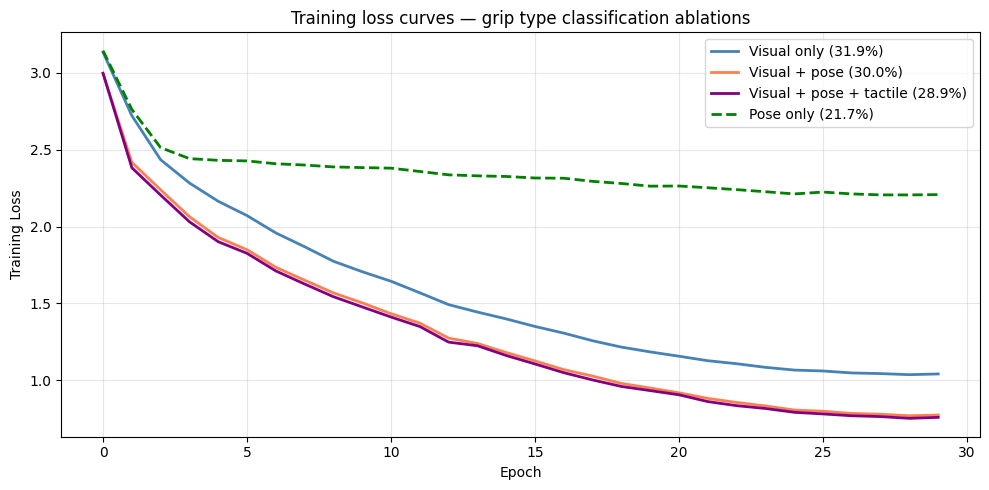

Saved to Drive


In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

epochs = list(range(30))

run1_loss = [3.1355, 2.7223, 2.4351, 2.2837, 2.1646, 2.0714, 1.9586, 1.8686,
             1.7742, 1.7061, 1.6440, 1.5687, 1.4917, 1.4434, 1.3987, 1.3496,
             1.3062, 1.2565, 1.2152, 1.1840, 1.1558, 1.1267, 1.1071, 1.0836,
             1.0658, 1.0598, 1.0470, 1.0429, 1.0358, 1.0406]
run2_loss = [2.9956, 2.4177, 2.2390, 2.0644, 1.9289, 1.8492, 1.7350, 1.6506,
             1.5683, 1.5031, 1.4327, 1.3712, 1.2738, 1.2389, 1.1797, 1.1254,
             1.0685, 1.0264, 0.9787, 0.9486, 0.9177, 0.8812, 0.8549, 0.8322,
             0.8056, 0.7974, 0.7834, 0.7782, 0.7683, 0.7732]
run3_loss = [2.9984, 2.3831, 2.2050, 2.0312, 1.9014, 1.8257, 1.7112, 1.6259,
             1.5434, 1.4769, 1.4110, 1.3492, 1.2476, 1.2242, 1.1606, 1.1055,
             1.0486, 1.0015, 0.9590, 0.9321, 0.9047, 0.8605, 0.8340, 0.8157,
             0.7909, 0.7801, 0.7683, 0.7629, 0.7515, 0.7581]
run4_loss = [3.1449, 2.7629, 2.5139, 2.4423, 2.4314, 2.4274, 2.4090, 2.4006,
             2.3884, 2.3839, 2.3803, 2.3587, 2.3367, 2.3303, 2.3262, 2.3162,
             2.3147, 2.2944, 2.2805, 2.2631, 2.2640, 2.2527, 2.2405, 2.2268,
             2.2126, 2.2246, 2.2126, 2.2063, 2.2061, 2.2080]

# Results table
results = {
    'Run': ['1', '2', '3', '4'],
    'Modalities': ['Visual', 'Visual + Pose', 'Visual + Pose + Tactile', 'Pose only'],
    'Test Accuracy': ['31.9%', '30.0%', '28.9%', '21.7%'],
    'Macro F1': ['0.169', '0.135', '0.144', '0.043'],
    'Train Loss (ep.29)': ['1.041', '0.773', '0.758', '2.208'],
}
print('=== Results Summary ===')
print(pd.DataFrame(results).to_string(index=False))
print('\nRandom chance baseline: 3.6% (1/28 classes)')

# Training loss curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, run1_loss, label='Visual only (31.9%)',
        color='steelblue', linewidth=2)
ax.plot(epochs, run2_loss, label='Visual + pose (30.0%)',
        color='coral', linewidth=2)
ax.plot(epochs, run3_loss, label='Visual + pose + tactile (28.9%)',
        color='purple', linewidth=2)
ax.plot(epochs, run4_loss, label='Pose only (21.7%)',
        color='green', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training loss curves — grip type classification ablations')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save everything to Drive
!cp training_loss_curves.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/training_loss_curves.png
print('Saved to Drive')

## Run 1, 60 epochs

Another follow-up if there's time

In [6]:
# 60-epoch visual run
!python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual \
    --batch-size 64 --lr 3e-3 --epochs 60 \
    --report-to tensorboard \
    --name run1_visual_60ep_v2 \
    --device cuda \
    --workers 2 \
    --save-frequency 60 \
    --val-frequency 100 \
    --logs /content/opentouch/logs

2026-04-07,10:49:03 | INFO | Running with a single process. Device cuda.
┬ D2: <dict object at 0x7f4726321dc0>
└ # D2 [2 B]
2026-04-07,10:51:08 | INFO | Classification split 'train': 1979 samples from 1979 clips.
┬ D2: <dict object at 0x7f47240fcac0>
└ # D2 [2 B]
2026-04-07,10:53:09 | INFO | Classification split 'val': 259 samples from 259 clips.
2026-04-07,10:53:09 | INFO | Discovered num_classes from data: 28
2026-04-07,10:53:09 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
2026-04-07,10:53:09 | INFO | HTTP Request: GET https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
config.json: 100% 744/744 [00:00<00:00, 3.76MB/s]
2026-04-07,10:53:09 | INFO | HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
loading configuration file config.json from cache at /ro

In [7]:
!python -m opentouch_train.classification_eval \
    --checkpoint /content/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt \
    --data preprocessed_data/classification_peak \
    --device cuda \
    --batch-size 8 \
    --workers 2

Model: OpenTouch-DINOv3-B16-Classify  Task: grip  Modalities: ['visual']  Epoch: 59
Classification split 'test': 263 samples from 263 clips.
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/facebook/dinov3-vitb16-pretrain-lvd1689m/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100% 211/211 [00:00<00:00, 688.40it/s, Materializing param=norm.weight]
Loaded checkpoint from '/content/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt'
Split: test  samples: 263  classes: 28

  Checkpoint : /content/opentouch/logs/run1_visual_60ep_v2/checkpoints/epoch_latest.pt
  Split      : test  (263 samples)
  Task       : grip  (28 classes: ['Adducted Thumb', 'Extension Type', 'Fixed Hook', 'Index Finger Extension', 'Large Diameter', 'Lateral', 'Lateral Tripod', 'Light Tool', 'Medium Wrap', 'Palmar', 'Palmar Pinch', 'Parallel Extension', 'Power Disk', 'Power Sph

In [8]:
!cp -r /content/opentouch/logs/run1_visual_60ep_v2 \
    /content/drive/MyDrive/6.S985/opentouch/logs/

Visual-only run comparisons

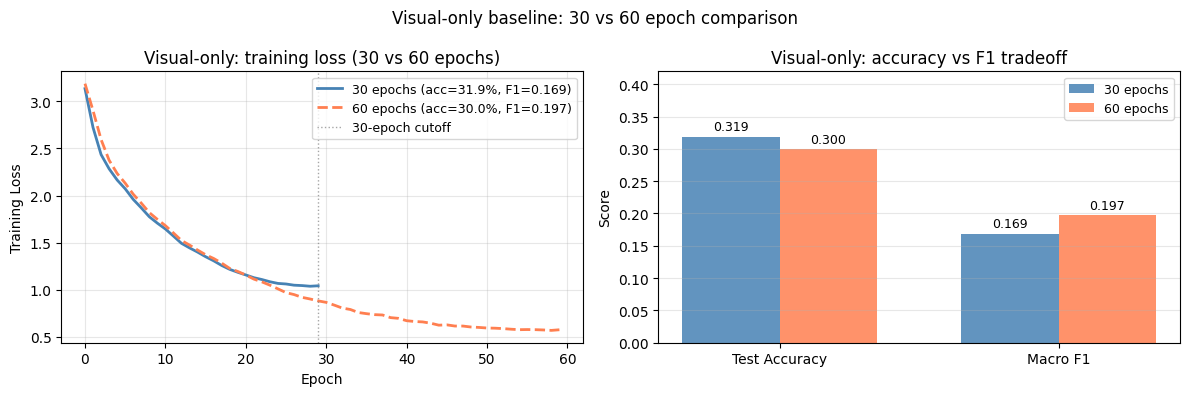

Saved


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 30-epoch run (Run 1)
run1_30ep = [3.1355, 2.7223, 2.4351, 2.2837, 2.1646, 2.0714, 1.9586, 1.8686,
             1.7742, 1.7061, 1.6440, 1.5687, 1.4917, 1.4434, 1.3987, 1.3496,
             1.3062, 1.2565, 1.2152, 1.1840, 1.1558, 1.1267, 1.1071, 1.0836,
             1.0658, 1.0598, 1.0470, 1.0429, 1.0358, 1.0406]

# 60-epoch run
run1_60ep = [3.1884, 2.9021, 2.5948, 2.3748, 2.2341, 2.1309, 2.0135, 1.9188,
             1.8181, 1.7466, 1.6797, 1.6015, 1.5218, 1.4734, 1.4203, 1.3706,
             1.3309, 1.2814, 1.2249, 1.1928, 1.1550, 1.1117, 1.0822, 1.0471,
             1.0077, 0.9680, 0.9472, 0.9177, 0.9002, 0.8802, 0.8644, 0.8352,
             0.8038, 0.7888, 0.7566, 0.7444, 0.7341, 0.7304, 0.7023, 0.6944,
             0.6695, 0.6611, 0.6567, 0.6429, 0.6221, 0.6255, 0.6129, 0.6128,
             0.6025, 0.5981, 0.5919, 0.5901, 0.5856, 0.5792, 0.5742, 0.5756,
             0.5743, 0.5713, 0.5667, 0.5733]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: training loss comparison
axes[0].plot(range(30), run1_30ep, label='30 epochs (acc=31.9%, F1=0.169)',
             color='steelblue', linewidth=2)
axes[0].plot(range(60), run1_60ep, label='60 epochs (acc=30.0%, F1=0.197)',
             color='coral', linewidth=2, linestyle='--')
axes[0].axvline(29, color='gray', linestyle=':', linewidth=1, alpha=0.7,
                label='30-epoch cutoff')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Visual-only: training loss (30 vs 60 epochs)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: bar chart comparing test accuracy and macro F1
metrics = ['Test Accuracy', 'Macro F1']
vals_30 = [0.319, 0.169]
vals_60 = [0.300, 0.197]
x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, vals_30, width, label='30 epochs',
                     color='steelblue', alpha=0.85)
bars2 = axes[1].bar(x + width/2, vals_60, width, label='60 epochs',
                     color='coral', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylabel('Score')
axes[1].set_title('Visual-only: accuracy vs F1 tradeoff')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 0.42)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Visual-only baseline: 30 vs 60 epoch comparison', fontsize=12)
plt.tight_layout()
plt.savefig('visual_only_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

!cp visual_only_comparison.png \
    /content/drive/MyDrive/6.S985/opentouch/logs/visual_only_comparison.png
print('Saved')